In [76]:
import torch 
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from helper_function import plot_predictions, accuracy_fn

In [157]:
weight = 0.7
bias = 0.3

torch.manual_seed(42)

X = torch.arange(0, 10, 0.1).unsqueeze(dim=1)
y = bias + weight * X

In [158]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

len(y_train)

80

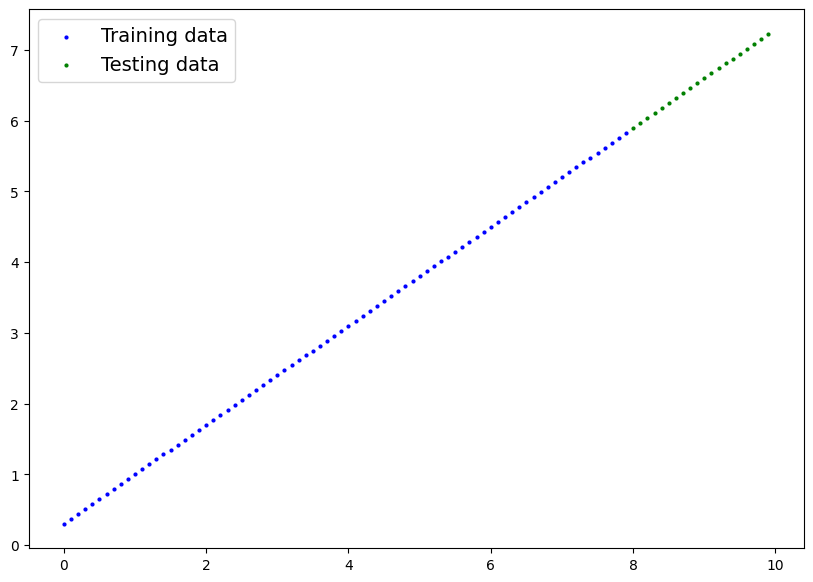

In [159]:
plot_predictions(X_train, y_train, X_test, y_test)

In [160]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [161]:
X_train.shape

torch.Size([80, 1])

In [162]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(
            in_features = 1, out_features = 10
        )
        self.layer_2 = nn.Linear(
            in_features = 10, out_features = 10
        )
        self.layer_3 = nn.Linear(
            in_features = 10, out_features = 1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.layer_2(self.layer_1(x)))

In [163]:
model = LinearRegressionModel().to(device)
model

LinearRegressionModel(
  (layer_1): Linear(in_features=1, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [164]:
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

In [165]:
total_epochs = []
train_losses = []
test_losses = []

In [166]:
def train_model(model, epochs, loss_fn, optimizer):
    for epoch in range(epochs):
        model.train()

        y_pred = model(X_train)
        train_accuracy = accuracy_fn(y_train, y_pred)

        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        train_losses.append(
            loss.item()
        )

        model.eval()
        with torch.inference_mode():
            y_test_pred = model(X_test)
            test_accuracy = accuracy_fn(y_test, y_test_pred)
            test_loss = loss_fn(y_test_pred, y_test)

            test_losses.append(
                test_loss.item()
            )

        total_epochs.append(
            epoch
        )

        if epoch % (0.1 * epochs) == 0:
            print(f"Training Loss: {loss:.5f} | Testing Loss: {test_loss:.5f}")
            print(f"Training Accuracy: {train_accuracy} | Testing Accuracy: {test_accuracy}\n")

        return {"train_y_pred": y_pred, "test_y_pred": y_test_pred}

In [167]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(
    params = model.parameters(), lr = 0.01
)

In [171]:
result = train_model(model, 100, loss_fn, optimizer)

Training Loss: 1.52530 | Testing Loss: 1.24807
Training Accuracy: 0.0 | Testing Accuracy: 0.0



In [172]:
with torch.inference_mode():
    y_test_pred = model(X_test)

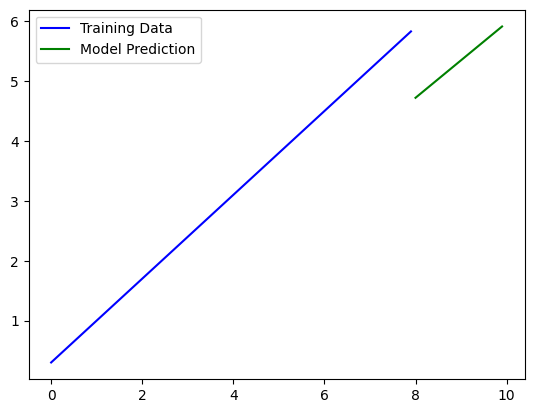

In [173]:
plt.plot(X_train.detach().cpu(), y_train.detach().cpu(), label = "Training Data", c = "blue")
plt.plot(X_test.detach().cpu(), y_test_pred.detach().cpu(), label = "Model Prediction", c = "green")
plt.legend()
plt.show()